In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: []


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import zipfile

zip_path = "/content/drive/MyDrive/archive.zip"
extract_path = "/content/plantvillage"

print("Zip var mı?:", os.path.exists(zip_path))

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Zip açıldı.")
else:
    print("Zip zaten açılmış.")

print(os.listdir(extract_path))

Zip var mı?: True
Zip açıldı.
['plantvillage', 'PlantVillage']


In [4]:
import os

data_dir = "/content/plantvillage/PlantVillage"

print("Veri klasörü var mı?:", os.path.exists(data_dir))
print("Sınıf sayısı:", len(os.listdir(data_dir)))
print("İlk 10 sınıf:", os.listdir(data_dir)[:10])

Veri klasörü var mı?: True
Sınıf sayısı: 15
İlk 10 sınıf: ['Tomato_Bacterial_spot', 'Pepper__bell___Bacterial_spot', 'Tomato_Leaf_Mold', 'Pepper__bell___healthy', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato_healthy', 'Tomato_Early_blight', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Potato___healthy']


In [5]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_dataset = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_dataset = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

class_names = train_dataset.class_names
num_classes = len(class_names)

print("Sınıf sayısı:", num_classes)
print("Sınıflar:", class_names)

Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.
Sınıf sayısı: 15
Sınıflar: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)

In [6]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
])

In [7]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,625,871 (10.02 MB)

 Trainable params: 365,327 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [10]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "best_plant_disease_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7
    )
]

In [11]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 53s 79ms/step - accuracy: 0.6623 - loss: 1.0645 - val_accuracy: 0.8532 - val_loss: 0.4456 - learning_rate: 5.0000e-04
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 75s 76ms/step - accuracy: 0.8002 - loss: 0.6099 - val_accuracy: 0.8687 - val_loss: 0.3757 - learning_rate: 5.0000e-04
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 40s 78ms/step - accuracy: 0.8307 - loss: 0.5162 - val_accuracy: 0.8842 - val_loss: 0.3343 - learning_rate: 5.0000e-04
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 41s 77ms/step - accuracy: 0.8479 - loss: 0.4518 - val_accuracy: 0.8914 - val_loss: 0.3122 - learning_rate: 5.0000e-04
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 41s 77ms/step - accuracy: 0.8612 - loss: 0.4286 - val_accuracy: 0.8912 - val_loss: 0.3126 - learning_rate: 5.0000e-04
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 43s 83ms/step - accuracy: 0.8654 - loss: 0.4037 - val_accuracy: 0.9026 - val_loss: 0.2908 - learning_rate: 5.0000e-04
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 40s 78ms/ste

In [12]:
val_loss, val_acc = model.evaluate(val_dataset)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_acc)

129/129 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - accuracy: 0.9125 - loss: 0.2517
Validation Loss: 0.2517242729663849
Validation Accuracy: 0.9125272631645203


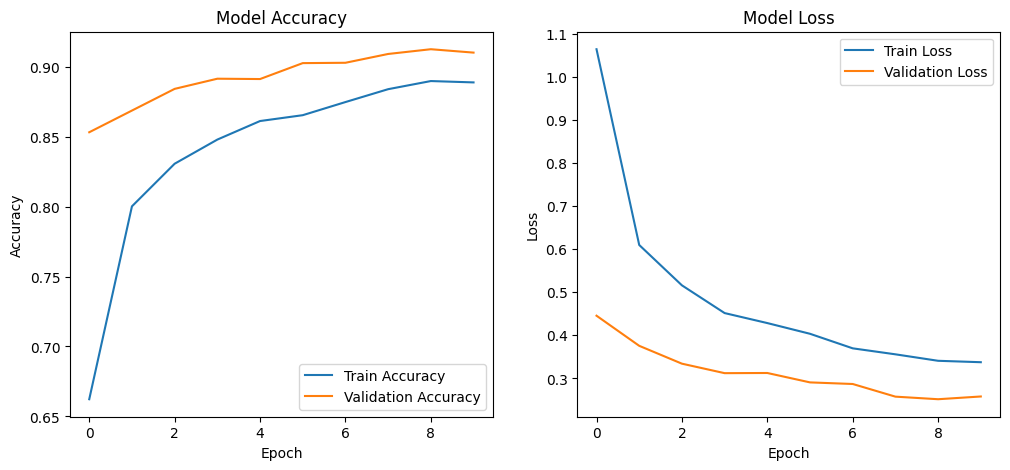

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [14]:
model.save("bitki_hastalik_tespiti_mobilenetv2.keras")
print("Model kaydedildi.")

Model kaydedildi.
